<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    margin-bottom: 25px;
">
    <img
        src="images/ibm_research_logo.jpeg"
        alt="IBM Research"
        style="max-height: 65px; max-width: 42%; width: auto;"
    >
</div>

<hr>

<div style="text-align: center; margin-top: 25px;">

# FactReasoner + Ollama

### A hands-on tutorial on probabilistic factuality assessment with examples from NASA

**Lecturer:** Javier Carnerero Cano  
**Affiliation:** IBM Research, Ireland

<hr>

<div style="
    display: flex;
    justify-content: space-between;
    align-items: center;
    margin-bottom: 25px;
">
    <img
        src="images/ictp_logo.png"
        alt="ICTP"
        style="max-height: 80px; max-width: 42%; width: auto;"
    >

</div>



<div style="text-align: center; margin-top: 25px;">

**Advanced School in Applied Machine Learning: Uncertainty and Robustness of DL Models for Science** 

31st July 2026

</div>

**Runtime:** macOS or Linux, local Ollama, internet access for Wikipedia retrieval  
**Pinned software:** `fact_reasoner==0.8.0`, Python 3.11+, `qwen2.5:1.5b`

By the end of the session, you will be able to:

1. Explain FactReasoner's atom → evidence → NLI → graphical-inference pipeline.
2. Run a small factuality assessment through a local Ollama model.
3. Inspect retrieved evidence, NLI relations, and posterior support probabilities.
4. Compare token-logprob and SIMBA-UQ approaches to NLI confidence.
5. Explain why NLI batching can be slow and choose sensible cost controls.

> This notebook was reviewed against [IBM/FactReasoner 0.8.0](https://github.com/IBM/FactReasoner/tree/727e73ec28d6e31fbb7421f09c09c099c54bf41a), released on 30 July 2026. FactReasoner is evolving quickly, so keep the version pin for a reproducible class.

## Start here: install everything once

Do this **before the tutorial**. These are the working commands for CINECA Leonardo and require no administrator privileges. Run downloads and package installation from a Leonardo **login node**; compute nodes may report `Network is unreachable` for PyPI and the Ollama registry. Run Jupyter and Ollama inference only inside the allocated compute job.

The setup uses these shared paths:

| Component | Location |
|---|---|
| `uv` | `$HOME/.local/bin/uv` |
| Python environment | `$HOME/.venvs/fact-reasoner` |
| Ollama application | `$HOME/.local/ollama` |
| Ollama models | `$SCRATCH/ollama-models` |

### 1. Install `uv` and the Python 3.11 environment on the login node

```bash
mkdir -p "$HOME/.local/bin" "$HOME/.venvs"
if [ ! -x "$HOME/.local/bin/uv" ]; then
  curl -LsSf https://astral.sh/uv/install.sh | \
    env UV_UNMANAGED_INSTALL="$HOME/.local/bin" sh
fi
export PATH="$HOME/.local/bin:$PATH"

ENV_DIR="$HOME/.venvs/fact-reasoner"
test -x "$ENV_DIR/bin/python" || uv venv --python 3.11 "$ENV_DIR"
uv pip install --python "$ENV_DIR/bin/python" \
  "fact_reasoner==0.8.0" "mellea==0.6.0" jupyterlab ipykernel

"$ENV_DIR/bin/python" -m ipykernel install --user \
  --name fact-reasoner \
  --display-name "Python 3.11 (FactReasoner)"
```

FactReasoner installs its Python dependencies—including pandas, NumPy, scikit-learn, sentence-transformers, ROUGE, and the Wikipedia client—automatically.

### 2. Install Ollama in your home directory without `sudo`

Leonardo's `tar` does not recognize `--zstd`, so decompress with the standalone `zstd` command and pipe the result into `tar`:

```bash
OLLAMA_HOME="$HOME/.local/ollama"
OLLAMA_ARCHIVE="$SCRATCH/ollama-linux-amd64.tar.zst"

mkdir -p "$OLLAMA_HOME"
curl -fL --retry 3 \
  https://ollama.com/download/ollama-linux-amd64.tar.zst \
  -o "$OLLAMA_ARCHIVE"

command -v zstd >/dev/null 2>&1 || module load zstd
zstd -dc "$OLLAMA_ARCHIVE" | tar -xf - -C "$OLLAMA_HOME"

export PATH="$OLLAMA_HOME/bin:$PATH"
export LD_LIBRARY_PATH="$OLLAMA_HOME/lib/ollama:${LD_LIBRARY_PATH:-}"
ollama --version
```

Ollama is a native application, not a Python package. Do not run its system installer on Leonardo because that installer targets privileged system directories.

### 3. Download the model once from the login node

The compute node cannot reach `registry.ollama.ai`. Use a temporary Ollama server on the login node only for the download, write the model into shared scratch, and stop that server immediately afterward:

```bash
(
  OLLAMA_HOME="$HOME/.local/ollama"
  export PATH="$OLLAMA_HOME/bin:$PATH"
  export LD_LIBRARY_PATH="$OLLAMA_HOME/lib/ollama:${LD_LIBRARY_PATH:-}"
  export OLLAMA_MODELS="$SCRATCH/ollama-models"
  export OLLAMA_HOST="127.0.0.1:11409"
  mkdir -p "$OLLAMA_MODELS"

  ollama serve >"$SCRATCH/ollama-download.log" 2>&1 &
  download_server_pid=$!
  trap 'kill "$download_server_pid" 2>/dev/null' EXIT

  for attempt in $(seq 1 30); do
    curl -fsS "http://$OLLAMA_HOST/api/version" >/dev/null && break
    sleep 1
  done

  ollama pull qwen2.5:1.5b
)
```

The model is stored in shared scratch at:

```text
$SCRATCH/ollama-models
```


### 4. Install the Boost libraries required by Merlin

Merlin is a standalone solver written in C++ that implements state-of-the-art exact and approximate algorithms for probabilistic inference over graphical models including both directed and undirected models such as Bayesian and Markov networks. Merlin supports the most common probabilistic inference tasks such as computing the partition function or probability of evidence (PR), posterior marginals (MAR), as well as MAP (also known as maximum aposteriori or most probable explanation) and Marginal MAP configurations. In addition, Merlin supports maximum likelihoood (EM) parameter learning for Bayesian networks only.

Specifically, in our experiments, we use an approximate variational inference algorithm called Weighted Mini-Buckets to compute the marginals. The algorithm is extremely efficient in practice.

Merlin is a C++ program, so it must be downloaded and compiled before running the notebook. Run these commands in a Leonardo terminal, preferably on the login node.

Leonardo's Boost module has the headers but lacks some compiled components required by Merlin. Install a private Boost build:

```bash
module load gcc/11.3.0

mkdir -p "$HOME/src"
cd "$HOME/src"

curl -fL \
  -o boost_1_80_0.tar.gz \
  https://archives.boost.io/release/1.80.0/source/boost_1_80_0.tar.gz

tar -xzf boost_1_80_0.tar.gz
cd boost_1_80_0

./bootstrap.sh \
  --prefix="$HOME/.local/boost-1.80.0" \
  --with-libraries=atomic,chrono,date_time,program_options,system,thread

./b2 \
  -j2 \
  variant=release \
  link=shared \
  threading=multi \
  install
```

Verify the installation:

```bash
ls "$HOME/.local/boost-1.80.0/lib"/libboost_program_options*
ls "$HOME/.local/boost-1.80.0/lib"/libboost_thread*
ls "$HOME/.local/boost-1.80.0/lib"/libboost_chrono*
ls "$HOME/.local/boost-1.80.0/lib"/libboost_atomic*
```

### 5. Download and patch Merlin

```bash
cd "$HOME"

if [ ! -d "$HOME/merlin/.git" ]; then
  git clone https://github.com/radum2275/merlin "$HOME/merlin"
fi

cd "$HOME/merlin"
```

Merlin's `CMakeLists.txt` contains a second Boost lookup that replaces the selected Boost path with the macOS-only path `/opt/homebrew/opt/boost`. Remove that block:

```bash
sed -i.bak \
  '/# Optionally specify Boost root if installed via Homebrew/,/find_package(Boost REQUIRED COMPONENTS program_options thread)/d' \
  CMakeLists.txt
```

Verify that only one Boost lookup remains:

```bash
grep -nE 'find_package\(Boost|homebrew' CMakeLists.txt
```

The expected output contains one `find_package(Boost ...)` line and no `homebrew` line.


### 6. Build Merlin

```bash
module unload boost/1.80.0--openmpi--4.1.4--gcc--11.3.0 \
  2>/dev/null || true

module load gcc/11.3.0

export LOCAL_BOOST_DIR="$HOME/.local/boost-1.80.0"
export LD_LIBRARY_PATH="$LOCAL_BOOST_DIR/lib:${LD_LIBRARY_PATH:-}"

mkdir -p "$HOME/merlin/build"
cd "$HOME/merlin/build"

rm -f CMakeCache.txt
rm -rf CMakeFiles

cmake \
  -DBoost_NO_BOOST_CMAKE=ON \
  -DBoost_NO_SYSTEM_PATHS=ON \
  -DBoost_INCLUDE_DIR="$LOCAL_BOOST_DIR/include" \
  -DBoost_LIBRARY_DIR_RELEASE="$LOCAL_BOOST_DIR/lib" \
  -DBoost_LIBRARY_DIR_DEBUG="$LOCAL_BOOST_DIR/lib" \
  -DBOOST_ROOT="$LOCAL_BOOST_DIR" \
  -DBOOST_INCLUDEDIR="$LOCAL_BOOST_DIR/include" \
  -DBOOST_LIBRARYDIR="$LOCAL_BOOST_DIR/lib" \
  -DCMAKE_BUILD_TYPE=Release \
  -DMERLIN_BUILD_TESTS=OFF \
  ..
```

Continue only after CMake reports:

```text
-- Configuring done
-- Generating done
```

Compile and test:

```bash
cmake --build . --parallel 8
./merlin --help
```

The executable is now located at:

```text
$HOME/merlin/build/merlin
```

Export Merlin path:

```bash
export MERLIN_PATH="$HOME/merlin/build/merlin"
```

### If CMake is unavailable

Install CMake and Ninja in the FactReasoner environment from the login node:

```bash
$HOME/.local/bin/uv pip install \
    --python "$HOME/.venvs/fact-reasoner/bin/python" \
    cmake ninja

hash -r

export MERLIN_PATH="$HOME/merlin/build/merlin"
```

`hash -r` clears Bash's remembered command locations so the newly installed commands can be found.

### If `make` does not work

If the terminal reports `make: command not found`, use Ninja instead. Create a separate build directory because CMake cannot change the generator of an existing build directory:

```bash
cd "$HOME/merlin"
mkdir -p build-ninja
cd build-ninja

cmake -G Ninja ..
ninja
./merlin --help

export MERLIN_PATH="$HOME/merlin/build/merlin"

```

If compilation starts but fails, look at the **first error message**. Common causes are a missing C++17 compiler or missing Boost libraries. Load the appropriate compiler and Boost modules on Leonardo, then run the build commands again.


### 7. Install sqlite3

Leonardo’s Python is linked to an old system SQLite. Chroma’s documented Linux workaround is to install pysqlite3-binary and substitute it before importing Chroma.

Do not run this from the compute-node notebook:

```bash
"$HOME/.local/bin/uv" pip install \
  --python "$HOME/.venvs/fact-reasoner/bin/python" \
  pysqlite3-binary
```


### 8. Add the runtime paths to `launch_Jupyter.sh`

Add these lines before starting Jupyter:

In [ ]:
%%bash
module load gcc/11.3.0

export PATH="$HOME/.venvs/fact-reasoner/bin:$SCRATCH/.local/ollama/bin:$PATH"

export MERLIN_PATH="$HOME/merlin/build/merlin"
export OLLAMA_MODELS="$SCRATCH/ollama-models"
export OLLAMA_HOST="127.0.0.1:11434"

export LD_LIBRARY_PATH="$HOME/.local/boost-1.80.0/lib:$SCRATCH/.local/ollama/lib/ollama:${LD_LIBRARY_PATH:-}"

source "$HOME/.venvs/fact-reasoner/bin/activate"

The local Boost path must be present whenever Merlin runs because Merlin links against the Boost shared libraries.


### 9. Launch the Leonardo job and select the installed kernel

Launch Jupyter inside the Slurm allocation as usual. In Jupyter, select **Kernel → Change Kernel → Python 3.11 (FactReasoner)**. The next cell does not install packages; it configures the user-space Ollama paths and starts the server on the same compute node as the notebook.

> This unchanged tutorial performs live Wikipedia retrieval. The allocated compute node must be able to reach Wikipedia at runtime; package installation and a local Ollama model do not replace that network requirement.

In [12]:
# Leonardo runtime bootstrap: no packages are installed from the compute node.
import os
import subprocess
import sys
import time
from pathlib import Path
from urllib.request import urlopen

if sys.version_info < (3, 11):
    raise RuntimeError(
        "Select Kernel → Change Kernel → Python 3.11 (FactReasoner) before continuing. "
        f"The current kernel is {sys.version.split()[0]} at {sys.executable}."
    )

OLLAMA_HOME = Path.home() / ".local/ollama"
OLLAMA_BIN = OLLAMA_HOME / "bin/ollama"
OLLAMA_LIB = OLLAMA_HOME / "lib/ollama"
OLLAMA_MODELS = Path(os.environ["SCRATCH"]) / "ollama-models"
OLLAMA_LOG = Path(os.environ["SCRATCH"]) / "ollama-server.log"
OLLAMA_API_VERSION = "http://127.0.0.1:11434/api/version"

if not OLLAMA_BIN.is_file():
    raise FileNotFoundError(f"Ollama is not installed at {OLLAMA_BIN}")

OLLAMA_MODELS.mkdir(parents=True, exist_ok=True)
ollama_env = os.environ.copy()
ollama_env["OLLAMA_HOST"] = "127.0.0.1:11434"
ollama_env["OLLAMA_MODELS"] = str(OLLAMA_MODELS)
ollama_env["LD_LIBRARY_PATH"] = (
    f"{OLLAMA_LIB}:{ollama_env.get('LD_LIBRARY_PATH', '')}"
)

try:
    print(urlopen(OLLAMA_API_VERSION, timeout=2).read().decode())
    print("Ollama server was already running on this compute node.")
except Exception:
    ollama_log_handle = OLLAMA_LOG.open("ab", buffering=0)
    ollama_process = subprocess.Popen(
        [str(OLLAMA_BIN), "serve"],
        env=ollama_env,
        stdout=ollama_log_handle,
        stderr=subprocess.STDOUT,
    )

    for _ in range(45):
        if ollama_process.poll() is not None:
            print(OLLAMA_LOG.read_text(errors="replace"))
            raise RuntimeError(
                f"Ollama exited with status {ollama_process.returncode}"
            )
        try:
            print(urlopen(OLLAMA_API_VERSION, timeout=2).read().decode())
            print("Ollama server is ready on this compute node.")
            break
        except Exception:
            time.sleep(1)
    else:
        print(OLLAMA_LOG.read_text(errors="replace"))
        raise RuntimeError("Ollama did not become ready within 45 seconds.")

{"version":"0.32.5"}
Ollama server is ready on this compute node.


In [13]:
# Test Qwen through the local Ollama server with a simple question.
import json
from urllib.request import Request, urlopen

prompt = "Who was Abdus Salam?"

payload = json.dumps({
    "model": "qwen2.5:1.5b",
    "prompt": prompt,
    "stream": False,
}).encode("utf-8")

request = Request(
    "http://127.0.0.1:11434/api/generate",
    data=payload,
    headers={"Content-Type": "application/json"},
)

with urlopen(request, timeout=300) as response:
    result = json.load(response)

print(result["response"].strip())

Abdus Salam (1926-1996) was a renowned Pakistani theoretical physicist who made significant contributions to the fields of quantum field theory and general relativity. Here are some key points about his life and work:

1. Education: Born in Lahore, Pakistan, Salam received his PhD from Cambridge University in 1950.

2. Research Focus: He specialized in mathematical physics, particularly in theoretical aspects of particle physics.

3. Nobel Prize: Salam was awarded the Nobel Prize in Physics in 1979 for "his services to Theoretical Physics, especially for the unification of the electroweak interaction through the discovery of the parity non-conserving weak nuclear force."

4. Particle Theory Contributions: He developed a theory that unified electromagnetic and weak forces at subatomic levels, known as electroweak theory.

5. Gravitational Fields: Salam also worked on quantum gravity theories, which aim to unify general relativity with quantum mechanics.

6. Education Institutions: He wa

## Specs

This lab deliberately uses:

- **Wikipedia retrieval**, so students do not need a Serper account or API key.
- NASA's **Apollo 15 hammer-and-feather demonstration**, a direct and accessible illustration of free fall in a near-vacuum.
- **FR1 graph shape** (`contexts_per_atom_only=True`) and `top_k=1`, so the live run stays small.
- **No context summarization stage**; the graph uses the retrieved Wikipedia passages directly.
- **Qwen2.5 1.5B**, a compact Q4 Ollama model selected for speed and reliable instruction/structured-output behavior.
- **SIMBA-UQ with four samples per NLI pair**, instead of the library default of twenty, to keep the live run inside the workshop window.
- The real **Merlin** executable when found, or an exact brute-force classroom fallback for the tiny graph.

The reduced SIMBA-UQ sampling budget is useful for teaching but gives less stable confidence estimates. Use the default sampling schedule and real Merlin for research results.

## Requirements

Use the Leonardo installation instructions at the beginning of this notebook, then confirm this checklist before class.

| Requirement | Version / purpose |
|---|---|
| Python | 3.11 or newer from `$HOME/.venvs/fact-reasoner` |
| `fact_reasoner` | Exactly `0.8.0` for the APIs used here |
| `mellea` | Exactly `0.6.0`; installed automatically by FactReasoner 0.8.0 |
| `jupyterlab`, `ipykernel` | Installed in the FactReasoner environment; kernel name `fact-reasoner` |
| NumPy, pandas, scikit-learn, sentence-transformers, ROUGE, Wikipedia client | Installed automatically as FactReasoner dependencies |
| Ollama | User-space installation at `$HOME/.local/ollama`; server runs on the allocated compute node |
| `qwen2.5:1.5b` | Downloaded before the job into `$SCRATCH/ollama-models`; approximately 986 MB in its default Q4 package |
| Network access | Login node needs PyPI/Ollama registry access during setup; the live compute job needs Wikipedia access |
| Merlin | Optional in this classroom notebook; the tiny example has an exact fallback |

> FactReasoner already declares pandas, NumPy, sentence-transformers, scikit-learn, ROUGE, and the Wikipedia client. Do not maintain a second hand-written list of versions for those transitive dependencies unless you are producing a fully locked environment.

## Pipeline at a glance

Read this once before running anything. FactReasoner is a traceable sequence, and uncertainty enters before the final score—not only at the end.

| Stage | What happens | Main output | Setting in this tutorial |
|---:|---|---|---|
| 0. Input | Receive the user query, candidate response, and topic | Text to assess | Two claims about Apollo 15's hammer-and-feather drop |
| 1. Atomize | Split the response into independently checkable factual claims | `Atom` objects | Qwen2.5 1.5B via Ollama |
| 2. Revise | Resolve pronouns and make each atom understandable on its own | Decontextualized atoms | Enabled with `revise_atoms=True` |
| 3. Retrieve | Search for evidence for each atom; an optional QueryBuilder can rewrite searches | Evidence `Context` objects | Wikipedia, `top_k=1`; QueryBuilder disabled |
| 4. Summarize *(optional)* | Compress or filter retrieved passages before NLI | Synthetic context summaries | **Skipped**: raw retrieved passages are used |
| 5. Schedule NLI pairs | Decide which atom–context and context–context pairs to evaluate | Candidate relation pairs | FR1 plus `all_pairs`; atom ↔ its own context only |
| 6. NLI + relation UQ | Classify each pair as entailment, contradiction, or neutral and estimate confidence | Typed relation + confidence | SIMBA-UQ, four samples per pair |
| 7. Build the fact graph | Connect atoms and contexts using the NLI relations | Fact graph | Atom–context edges only |
| 8. Build factors | Convert graph nodes, node priors, relation types, and confidences into a binary Markov network | Variables and factors | Default atom/context node priors; the pairwise tables use the `use_priors=False` variant |
| 9. Infer marginals | Run Merlin—or the exact tiny-graph tutorial fallback—to marginalize the network | `P(atom=True)` for every atom | Exact inference for the small lab graph |
| 10. Report and inspect | Aggregate atom probabilities and expose evidence, relations, timing, and entropy | Factuality score plus trace | Tables shown later in the notebook |

**Interpretation:** the final number is conditional on the retrieved evidence, the model's NLI judgments, the confidence estimator, and the graph assumptions. It is not an oracle for objective truth.

## Uncertainty quantification at a glance

FactReasoner exposes uncertainty at two levels: **confidence in each NLI relation** and the **posterior uncertainty of each atom after graph inference**.

| Method | How confidence is obtained | Backend / setup | When to use |
|---|---|---|---|
| Token log-probabilities | Generate an NLI label and derive confidence from the token log-probabilities over the generated label span | `nli_method="logprobs"`; requires a backend that returns log-probabilities, such as vLLM or RITS | Single-generation NLI-UQ path when log-probabilities are available |
| SIMBA-UQ aggregation | Generate multiple answers at several temperatures, compare their textual similarity, and use consensus as confidence | `nli_method="simbauq"`; works with Ollama; similarity can use ROUGE, Jaccard, SBERT, difflib, or Levenshtein | Default Ollama-compatible choice; no training data required |
| SIMBA-UQ classifier | Use the SIMBA-UQ similarity features as input to a previously trained probabilistic classifier | `simbauq_confidence_method="classifier"` plus a classifier object/path; training and inference sample schedules must match | Research setting with labeled calibration data |
| Graph posterior and entropy | Propagate relation confidences through the Markov network and summarize each atom's marginal probability and entropy | Produced after Merlin inference; not a separate NLI method | Interpret final support and uncertainty jointly |

This notebook uses **SIMBA-UQ aggregation with Jaccard similarity** because Ollama does not provide the token log-probabilities required by the first method. Its tutorial schedule uses two temperatures × two samples = four generations per NLI pair. FactReasoner's default is four temperatures × five samples = twenty.

> More samples can stabilize consensus but increase runtime nearly linearly per NLI pair. A confident relation can still be wrong when all samples agree for the wrong reason, so always inspect the retrieved passage and relation label.

## 75–80 minute plan

| Time | Activity |
|---:|---|
| 0–10 min | Motivation, complete pipeline recap, and UQ methods |
| 10–20 min | Environment and Ollama preflight |
| 20–30 min | FactReasoner graph versions and cost choices |
| 30–50 min | Build and run one local assessment |
| 50–65 min | Inspect atoms, evidence, NLI relations, and posteriors |
| 65–75 min | Student challenge and cost reasoning |
| 75–80 min | Limitations, production settings, and recap |

**Instructor cue:** before running any code, ask: *Is factuality a property of the sentence alone, or of the sentence relative to available evidence?*

## 1. What FactReasoner computes

FactReasoner treats a response as a set of short, independently checkable **atoms**. It retrieves **contexts** from an external source, asks a model for an NLI relationship between evidence and claim, constructs a binary Markov network, and computes a posterior probability for each atom.

| Stage | Question | Output |
|---|---|---|
| Atomize | What claims does the response make? | Atomic claims |
| Revise | Can each claim stand alone? | Decontextualized atoms |
| Retrieve | What evidence is relevant? | Context passages |
| NLI | Does a context entail, contradict, or remain neutral to an atom? | Relation + confidence |
| Infer | What support probability follows from all relations? | Posterior `P(atom=True)` |

A low score means **not supported by the retrieved evidence and model judgments**. It is not a mathematical proof that the claim is false.

## 2. Check the model

The complete one-time Leonardo installation is at the beginning of the notebook. Confirm that the model is already present in shared scratch and that the registered kernel is available:

```bash
source "$HOME/.venvs/fact-reasoner/bin/activate"
jupyter kernelspec list
test -d "$SCRATCH/ollama-models/manifests" && echo "Ollama model store found"
```

Launch Jupyter inside the Slurm allocation and choose **Python 3.11 (FactReasoner)**. Do not run `pip`, `uv pip install`, or `ollama pull` from the compute-node notebook: those downloads fail when the node has no outbound route. The runtime-bootstrap cell near the top starts `ollama serve` on the notebook's compute node using the model store in `$SCRATCH`.

If the Slurm job moves to a different node, restart the notebook kernel and rerun the runtime-bootstrap cell so Ollama starts on that new node.

## 3. Other checks

The notebook process and the Ollama server must run on the **same Leonardo compute node** for `127.0.0.1:11434` to work. Run the runtime-bootstrap cell near the top first, then run the next cell; it reports all common setup failures together.

In [17]:
# Leonardo's system SQLite is too old for ChromaDB.
# Replace Python's sqlite3 module with the newer pysqlite3 binary build.

import sys
import pysqlite3

sys.modules["sqlite3"] = sys.modules.pop("pysqlite3")

import sqlite3

print("SQLite version:", sqlite3.sqlite_version)

if sqlite3.sqlite_version_info < (3, 35, 0):
    raise RuntimeError(
        f"SQLite {sqlite3.sqlite_version} is still too old for ChromaDB"
    )

import chromadb

print("ChromaDB import succeeded")

SQLite version: 3.51.1
ChromaDB import succeeded


In [18]:
import json
import os
import platform
import shutil
import sys
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
from urllib.request import Request, urlopen

PACKAGE_REQUIREMENTS = {
    "fact_reasoner": "0.8.0",
    "mellea": "0.6.0",
    "pandas": None,
    "ipython": None,
    "ipykernel": None,
}
OLLAMA_TAG = "qwen2.5:1.5b"
OLLAMA_URL = "http://127.0.0.1:11434"

# SIMBA-UQ cost control. Total generations per NLI pair are:
# len(SIMBA_TEMPERATURES) * SIMBA_SAMPLES_PER_TEMPERATURE.
SIMBA_TEMPERATURES = [0.3, 0.7]
SIMBA_SAMPLES_PER_TEMPERATURE = 2
SIMBA_SAMPLES_PER_PAIR = len(SIMBA_TEMPERATURES) * SIMBA_SAMPLES_PER_TEMPERATURE

if not SIMBA_TEMPERATURES or SIMBA_SAMPLES_PER_TEMPERATURE <= 0:
    raise ValueError("SIMBA-UQ needs at least one temperature and a positive sample count.")

def find_merlin():
    """Return a local Merlin executable if one is available."""
    candidates = [
        os.getenv("MERLIN_PATH"),
        shutil.which("merlin"),
        Path.cwd() / "merlin" / "build" / "merlin",
        Path.cwd().parent / "merlin" / "build" / "merlin",
    ]
    for candidate in candidates:
        if candidate and Path(candidate).expanduser().is_file():
            return Path(candidate).expanduser().resolve()
    return None

print(f"Python executable: {sys.executable}")
print(f"Platform: {platform.platform()}")
print(f"SIMBA-UQ budget: {SIMBA_SAMPLES_PER_PAIR} generations per NLI pair")

Python executable: /leonardo/home/usertrain/a08trb09/.venvs/fact-reasoner/bin/python
Platform: Linux-4.18.0-477.27.1.el8_8.x86_64-x86_64-with-glibc2.28
SIMBA-UQ budget: 4 generations per NLI pair


In [19]:
# Each check is (name, passed, detail, required_to_continue).
checks = []

python_ok = sys.version_info >= (3, 11)
checks.append(("Python >= 3.11", python_ok, platform.python_version(), True))

for package_name, expected_version in PACKAGE_REQUIREMENTS.items():
    try:
        installed_version = version(package_name)
        package_ok = expected_version is None or installed_version == expected_version
        package_detail = installed_version
    except PackageNotFoundError:
        package_ok = False
        package_detail = "not installed"
    label = package_name if expected_version is None else f"{package_name} == {expected_version}"
    checks.append((label, package_ok, package_detail, True))

ollama_models = []
try:
    with urlopen(f"{OLLAMA_URL}/api/tags", timeout=5) as response:
        ollama_models = [m.get("name", "") for m in json.load(response).get("models", [])]
    ollama_ok = True
    ollama_detail = f"server ready; {len(ollama_models)} model(s)"
except Exception as exc:
    ollama_ok = False
    ollama_detail = f"{type(exc).__name__}: {exc}"
checks.append(("Ollama server", ollama_ok, ollama_detail, True))

model_ok = OLLAMA_TAG in ollama_models or any(
    name.startswith(f"{OLLAMA_TAG}@") for name in ollama_models
)
checks.append((f"Ollama model {OLLAMA_TAG}", model_ok, ", ".join(ollama_models) or "none", True))

real_merlin = find_merlin()
checks.append(("Merlin executable (optional here)", bool(real_merlin), str(real_merlin or "classroom fallback will be used"), False))

for name, ok, detail, _required in checks:
    icon = "PASS" if ok else "WARN"
    print(f"[{icon:4}] {name}: {detail}")

blocking = [name for name, ok, _detail, required in checks if required and not ok]
if blocking:
    raise RuntimeError(
        "Fix these items before continuing: " + ", ".join(blocking) + ". "
        f"For a missing model, run: ollama pull {OLLAMA_TAG}"
    )

[PASS] Python >= 3.11: 3.11.2
[PASS] fact_reasoner == 0.8.0: 0.8.0
[PASS] mellea == 0.6.0: 0.6.0
[PASS] pandas: 3.0.5
[PASS] ipython: 9.15.0
[PASS] ipykernel: 7.3.0
[PASS] Ollama server: server ready; 1 model(s)
[PASS] Ollama model qwen2.5:1.5b: qwen2.5:1.5b
[PASS] Merlin executable (optional here): /leonardo/home/usertrain/a08trb09/merlin/build/merlin


### Warm up the local model

The first model load is usually slower than later calls. This direct Ollama request verifies that the model—not just the server—is usable.

In [20]:
payload = json.dumps({
    "model": OLLAMA_TAG,
    "prompt": "Reply with exactly: READY",
    "stream": False,
    "keep_alive": "30m",
}).encode("utf-8")

request = Request(
    f"{OLLAMA_URL}/api/generate",
    data=payload,
    headers={"Content-Type": "application/json"},
)
with urlopen(request, timeout=300) as response:
    warmup = json.load(response)

print("Ollama response:", warmup.get("response", "").strip())

Ollama response: READY


## 4. Graph shape and cost are different choices

| Version | Graph relationships | Interpretation |
|---|---|---|
| FR1 / `v1` | Each atom ↔ its own contexts | Smallest; used in this live lab |
| FR2 / `v2` | Each atom ↔ all unique contexts | Cross-atom evidence sharing; current default |
| FR3 / `v3` | FR2 + context ↔ context | Richest and most expensive |

`pipeline_version` controls the graph. Separately, `nli_mode="all_pairs"` scores all candidate pairs, while `nli_mode="fast"` prunes candidates. Published/reproducible work should normally finish with `all_pairs`; exploratory work can start with `fast`.

**Ollama-specific rule:** use `nli_method="simbauq"`. Ollama does not expose the token log-probabilities required by FactReasoner's `logprobs` method.

## 5. Build the FactReasoner pipeline

FactReasoner normally calls the compiled Merlin solver. To make the lab robust across student laptops, the next cell uses Merlin when it is found and otherwise installs FactReasoner's exact brute-force test oracle as a **small-graph-only classroom fallback**. The fallback refuses networks above twenty binary variables and is not a production replacement.

In [21]:
import pandas as pd
from IPython.display import display

from fact_reasoner import FactReasoner, build_backend
from fact_reasoner.core.atomizer import Atomizer
from fact_reasoner.core.nli import NLIExtractor
from fact_reasoner.core.nli_config import get_pair_config
from fact_reasoner.core.retriever import ContextRetriever, SourceRetriever
from fact_reasoner.core.reviser import Reviser
from mellea.backends import ModelOption

real_merlin = find_merlin()
if real_merlin:
    MERLIN_PATH = str(real_merlin)
    USING_CLASSROOM_ORACLE = False
else:
    import fact_reasoner.assessor as assessor_module
    from fact_reasoner.experiments.mock import brute_force_run_merlin

    assessor_module._run_merlin_shared = brute_force_run_merlin
    MERLIN_PATH = "classroom-exact-oracle"
    USING_CLASSROOM_ORACLE = True

# A raw Ollama tag is supported by FactReasoner's backend factory.
# The 512-token cap prevents accidental long generations in this two-claim lab.
backend = build_backend(
    "ollama",
    model_id=OLLAMA_TAG,
    model_options={ModelOption.MAX_NEW_TOKENS: 512},
)
print("Mellea backend model:", backend.model_id)
print("Inference:", "exact classroom oracle" if USING_CLASSROOM_ORACLE else MERLIN_PATH)

/leonardo/home/usertrain/a08trb09/.venvs/fact-reasoner/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Mellea backend model: qwen2.5:1.5b
Inference: /leonardo/home/usertrain/a08trb09/merlin/build/merlin


In [22]:
def make_pipeline():
    """Create a fresh, deliberately small FactReasoner pipeline."""
    atomizer = Atomizer(backend)
    reviser = Reviser(backend)
    # Classroom budget: 2 temperatures × 2 samples = 4 generations per NLI pair.
    # FactReasoner's default is 4 × 5 = 20 and gives more stable confidence.
    nli = NLIExtractor(
        backend,
        nli_method="simbauq",
        simbauq_temperatures=SIMBA_TEMPERATURES,
        simbauq_n_per_temp=SIMBA_SAMPLES_PER_TEMPERATURE,
        simbauq_similarity_metric="jaccard",
        show_progress=True,
    )


    if RETRIEVAL_MODE == "offline":
        source = OfflineApolloRetriever(top_k=3)
    else:
        source = SourceRetriever(
            service_type="wikipedia",
            top_k=3,
            fetch_text=False,
            num_workers=2,
        )

    contexts = ContextRetriever(
        retriever=source,
        num_workers=2,
    )

    return FactReasoner(
        atom_extractor=atomizer,
        atom_reviser=reviser,
        context_retriever=contexts,
        nli_extractor=nli,
        merlin_path=MERLIN_PATH,
        use_priors=False,
        nli_pair_config=get_pair_config("all_pairs"),
        nli_cache_dir=".cache/factreasoner-nli",
    )


async def assess_response(response, query, topic):
    pipeline = make_pipeline()
    await pipeline.build(
        query=query,
        response=response,
        topic=topic,
        revise_atoms=True,
        remove_duplicates=False,
        summarize_contexts=False,
        contexts_per_atom_only=True,  # FR1 graph: atom ↔ its own contexts
        rel_atom_context=True,
        rel_context_context=False,
        use_fast_retriever=True,
    )
    results, _marginals = pipeline.score()
    return pipeline, results

## 6. Live assessment

The response contains one expected supported statement and one expected contradiction. Before running it, predict:

1. How many atoms will the atomizer produce?
2. What evidence page will Wikipedia return?
3. Will the second atom's probability be exactly zero? Why or why not?

Apollo 15 gives us a cleaner scientific case. Near the end of the mission's final moonwalk, Commander David Scott released a geological hammer and a falcon feather together. NASA reports that the 1.32 kg hammer and 0.03 kg feather were released from approximately 1.6 m and, within the accuracy of the release, underwent the same acceleration and struck the lunar surface simultaneously. See [NASA's experiment record and video](https://science.nasa.gov/resource/the-apollo-15-hammer-feather-drop/).

The physics is simple: when drag is negligible, $F_g=m_g g=m_i a$. If gravitational and inertial mass are equivalent, the test body's mass cancels and $a=g$. With $h\approx1.6\,\mathrm{m}$ and lunar $g\approx1.62\,\mathrm{m\,s^{-2}}$, an idealized drop time is $t\approx\sqrt{2h/g}\approx1.4\,\mathrm{s}$. This was a memorable qualitative demonstration of universal free fall, not a precision test of the equivalence principle. The live pipeline retrieves Wikipedia, while the NASA record supplies a clear reference answer.

> Timing varies by CPU/GPU and model load. The cell prints progress and timing. A message such as `Running throttled batch ...` means Mellea is limiting concurrent model requests; it does not by itself mean the process is stuck.

### The experiment on the Moon

[![Apollo 15 television still of David Scott performing the hammer-and-feather drop on the Moon](https://www.nasa.gov/wp-content/uploads/2021/07/apollo_15_moon_landing_31_feather_and_hammer_aug_2_1971_from_video_s71-43788.jpg)](https://www.nasa.gov/history/50-years-ago-apollo-15-on-the-moon-at-hadley-apennine/)

*Television still of Apollo 15 Commander David Scott performing the demonstration, NASA image S71-43788. Credit: NASA. [Read the NASA history article](https://www.nasa.gov/history/50-years-ago-apollo-15-on-the-moon-at-hadley-apennine/) or [watch/download NASA's experiment video](https://science.nasa.gov/resource/the-apollo-15-hammer-feather-drop/). Included for educational and informational use under [NASA's media usage guidelines](https://www.nasa.gov/nasa-brand-center/images-and-media/); no NASA endorsement is implied.*

In [23]:
QUERY = "What happened in Apollo 15's hammer-and-feather demonstration, and what physical principle did it illustrate?"
RESPONSE = (
    "During Apollo 15, David Scott dropped a geological hammer and a falcon feather together on the Moon. "
    "The hammer reached the lunar surface before the feather because it had greater mass."
)
TOPIC = "Apollo 15 hammer-and-feather experiment"

print("Query:", QUERY)
print("Response to assess:", RESPONSE)

Query: What happened in Apollo 15's hammer-and-feather demonstration, and what physical principle did it illustrate?
Response to assess: During Apollo 15, David Scott dropped a geological hammer and a falcon feather together on the Moon. The hammer reached the lunar surface before the feather because it had greater mass.


In [24]:
# Use "offline" on Leonardo compute nodes.
# Change to "wikipedia" only on a machine with outbound internet access.
RETRIEVAL_MODE = "offline"

if RETRIEVAL_MODE not in {"offline", "wikipedia", "google", "chromadb"}:
    raise ValueError(
        "RETRIEVAL_MODE must be 'offline', 'wikipedia', 'google', or 'chromadb'"
    )

print("Retrieval mode:", RETRIEVAL_MODE)

Retrieval mode: offline


In [25]:
class OfflineApolloRetriever:
    """Return locally embedded evidence without network access."""

    def __init__(self, top_k: int = 3):
        self.top_k = top_k

        self.evidence = [
            {
                "title": "NASA Apollo 15 Hammer-Feather Drop",
                "text": (
                    "During the final Apollo 15 lunar surface activity, Commander "
                    "David Scott released a 1.32-kilogram geological hammer and a "
                    "0.03-kilogram falcon feather simultaneously from approximately "
                    "1.6 meters. Within the accuracy of the release, both objects "
                    "underwent the same acceleration and struck the lunar surface "
                    "simultaneously. Because the experiment took place in an "
                    "essentially airless environment, air resistance did not cause "
                    "the feather to fall more slowly."
                ),
                "snippet": (
                    "The hammer and feather underwent the same acceleration and "
                    "struck the lunar surface simultaneously."
                ),
                "link": (
                    "https://science.nasa.gov/resource/"
                    "the-apollo-15-hammer-feather-drop/"
                ),
            },
            {
                "title": "NASA History: Apollo 15 at Hadley-Apennine",
                "text": (
                    "Apollo 15 Commander David Scott explained that Galileo had "
                    "made an important discovery about falling objects in "
                    "gravitational fields. Scott released a geological hammer and "
                    "a falcon feather together on the Moon. The hammer and feather "
                    "hit the lunar dust at the same time, demonstrating that the "
                    "heavier hammer did not reach the surface before the feather."
                ),
                "snippet": (
                    "Scott dropped a hammer and feather, and they hit the lunar "
                    "dust at the same time."
                ),
                "link": (
                    "https://www.nasa.gov/history/"
                    "50-years-ago-apollo-15-on-the-moon-at-hadley-apennine/"
                ),
            },
            {
                "title": "Synthetic Conflicting Report — Intentionally False",
                "text": (
                    "This synthetic teaching passage claims that David Scott released a "
                    "geological hammer and a falcon feather together during Apollo 15, but "
                    "that the hammer reached the lunar surface before the feather because "
                    "the hammer had greater mass. This passage is intentionally incorrect "
                    "and is included only to demonstrate conflicting evidence in the "
                    "FactReasoner graph."
                ),
                "snippet": (
                    "Intentionally false teaching claim: the heavier hammer landed before "
                    "the feather."
                ),
                "link": "local://synthetic-conflicting-evidence",
            },
        ]

    def query(self, text: str, max_size: int = 4000):
        # The `text` argument is accepted to match SourceRetriever's interface.
        return self.evidence[: self.top_k]

In [26]:
def make_context_retriever():
    if RETRIEVAL_MODE == "offline":
        source = OfflineApolloRetriever()
    else:
        source = SourceRetriever(
            service_type="wikipedia",
            top_k=1,
            fetch_text=False,
            num_workers=2,
        )

    return ContextRetriever(
        retriever=source,
        num_workers=2,
    )

In [27]:
source = OfflineApolloRetriever(top_k=3)

contexts = ContextRetriever(
    retriever=source,
    num_workers=2,
)

In [28]:
print("Retrieval mode:", RETRIEVAL_MODE)

offline_source = OfflineApolloRetriever(top_k=3)
test_hits = offline_source.query("Apollo 15 hammer and feather")

print("Offline hits:", len(test_hits))

for hit in test_hits:
    print("-", hit["title"])

assert len(test_hits) == 3, (
    "OfflineApolloRetriever should return three evidence passages"
)

Retrieval mode: offline
Offline hits: 3
- NASA Apollo 15 Hammer-Feather Drop
- NASA History: Apollo 15 at Hadley-Apennine
- Synthetic Conflicting Report — Intentionally False


In [29]:
from fact_reasoner.core.base import Atom
from fact_reasoner.core.retriever import ContextRetriever

test_wrapper = ContextRetriever(
    retriever=offline_source,
    num_workers=1,
)

test_atom = Atom(
    id="a_test",
    text="The hammer and feather landed simultaneously.",
)

test_contexts = test_wrapper.retrieve_all(
    atoms={"a_test": test_atom},
    query=None,
)

print("Wrapped contexts:", len(test_contexts))
print("Atom contexts:", len(test_atom.contexts))

assert len(test_contexts) == 3

Retrieving contexts: 100%|██████████| 1/1 [00:00<00:00, 13751.82it/s]

Wrapped contexts: 3
Atom contexts: 3


In [30]:
# Jupyter supports top-level await. Do not wrap this in asyncio.run().
pipeline, results = await assess_response(RESPONSE, QUERY, TOPIC)
print("Assessment complete.")

[Atomizer] Using Mellea backend: qwen2.5:1.5b
[Reviser] Using Mellea backend: qwen2.5:1.5b
[NLI] Using Mellea backend: qwen2.5:1.5b (method: simbauq)
[NLI] SIMBA-UQ strategy configuration:
[NLI]   temperatures       : [0.3, 0.7]
[NLI]   samples/temperature: 2
[NLI]   total samples      : 4   (len(temperatures) * n_per_temp)
[NLI]   similarity metric  : jaccard
[NLI]   confidence method  : aggregation (mean)
[FactReasoner] Using merlin at: /leonardo/home/usertrain/a08trb09/merlin/build/merlin
[FactReasoner] Using atom/context priors: False
[FactReasoner] Using NLI verdict cache at: .cache/factreasoner-nli
[FactReasoner] Building the pipeline ...
[FactReasoner] Extracting the atoms ...
[FactReasoner][TIMING] Atom extraction: 1.4387s
[FactReasoner] Extracted 2 atoms.
[FactReasoner] Atom a0: David Scott dropped a geological hammer and a falcon feather.
[FactReasoner] Atom a1: The hammer reached the lunar surface before the feather.
[FactReasoner] Revising the atoms ...
[FactReasoner][TIMIN

Retrieving contexts: 100%|██████████| 3/3 [00:00<00:00, 32017.59it/s]


[FactReasoner][TIMING] Context retrieval: 0.0019s
[FactReasoner] Retrieved 9 contexts.
[NLI] Building atom-context relations...
[NLI] Atom-context pairs: 6 selected, 12 pruned (of 18 possible).
[NLI] Processing 6 potential relationships ...
[NLI] Running throttled batch of 6 requests ...


NLI relations: 100%|██████████| 6/6 [00:26<00:00,  4.38s/rel]


[NLI] Found relation: [c_a0_0 -> a0] : entailment : 0.6015092375748113
[NLI] Found relation: [c_a0_1 -> a0] : entailment : 0.41092726751021424
[NLI] Found relation: [c_a1_0 -> a1] : contradiction : 0.39445199633519573
[NLI] Found relation: [c_a1_1 -> a1] : contradiction : 0.44834621921736256
[NLI] Found relation: [c_a1_2 -> a1] : contradiction : 0.4357854387088551
[NLI] Relations built: 5
[NLI] LLM calls: 6 (all_pairs equivalent: 18, 3.0x fewer)
[FactReasoner][TIMING] NLI relation extraction: 26.3053s
[FactReasoner] Building the graphical model ...


Relations: 100%|██████████| 5/5 [00:00<00:00, 132731.14it/s]

[FactReasoner][TIMING] Graphical model construction: 0.0027s
[FactReasoner][TIMING] build() total: 29.1234s
[FactReasoner] Pipeline instance created.
libmerlin 1.7.0
(c) Copyright IBM Corp. 2015 - 2019
All Rights Reserved
[MERLIN] Initialize Merlin engine ...
[MERLIN] + tasks supported  : PR, MAR, MAP, MMAP, EM
[WMB] + i-bound          : 6
[WMB] + iterations       : 10
[WMB] + inference task   : MAR
[WMB] + ordering method  : MinFill
[WMB] + order iterations : 100
[WMB] + elimination      : 2 3 4 5 6 7 8 9 10 0 1 
[WMB] + induced width    : 1
[WMB] + exact inference  : Yes
[WMB] + ordering time    : 5.50747e-05 seconds
[WMB] Created join graph with 11 clique factors
[WMB] Number of cliques  : 11
[WMB] Number of edges    : 10
[WMB] Max clique size    : 2
[WMB] Max separator size : 1
[WMB] Finished initialization in 0.000144005 seconds
[WMB] Begin message passing over join graph ...
  logZ:    -3.487273 (3.058416e-02) 	d=3.487273e+00	 time=0.000211	i=1
[WMB] Converged after 1 iterations 

In [32]:
print(results)

{'factuality_score_per_atom': [{'a0': {'score': 0.50816, 'support': 'S'}}, {'a1': {'score': 0.69357, 'support': 'S'}}], 'factuality_score': 1.0, 'recall_k': 1.0, 'f1_k': 1.0, 'num_atoms': 2, 'num_contexts': 9, 'num_true_atoms': 2, 'num_false_atoms': 0, 'num_uniform_atoms': 0, 'entropy': 0.5977828629260346, 'norm_entropy': 1.8888173009789644, 'avg_entropy': 0.2988914314630173, 'avg_norm_entropy': 0.9444086504894822, 'avg_prob': 0.600865, 'avg_logprob': -0.5214310137049011, 'avg_explogprob': 0.5936703893575963, 'marginals': [{'variable': 'a0', 'probabilities': [0.49184, 0.50816]}, {'variable': 'a1', 'probabilities': [0.30643, 0.69357]}], 'predictions': {'a0': 'S', 'a1': 'S'}, 'nli_stats': {'policy': 'all_pairs', 'gate_backend': None, 'gate_threshold': None, 'cascade': False, 'num_atoms': 2, 'num_contexts': 9, 'atom_context': {'policy': 'all_pairs', 'num_atoms': 2, 'num_contexts': 9, 'pairs_possible': 18, 'contexts_per_atom_only': True, 'pairs_selected': 6, 'pairs_pruned': 12, 'gate_thres

## 7. Inspect, do not just accept the score

A single aggregate number hides the interesting parts. Inspect the atom text, the exact retrieved context, the NLI edge, and the posterior together.

In [71]:
def shorten(text, width=260):
    cleaned = " ".join((text or "").split())
    return cleaned if len(cleaned) <= width else cleaned[: width - 1] + "…"


def show_result_tables(pipeline, results):
    summary = pd.DataFrame([
        {"metric": "factuality_score", "value": results.get("factuality_score")},
        {"metric": "num_atoms", "value": results.get("num_atoms")},
        {"metric": "num_contexts", "value": results.get("num_contexts")},
        {"metric": "avg_probability", "value": results.get("avg_prob")},
        {"metric": "average_normalized_entropy", "value": results.get("avg_norm_entropy")},
        {"metric": "elapsed_seconds", "value": results.get("elapsed_time")},
    ])

    atom_rows = []
    for item in results.get("factuality_score_per_atom", []):
        atom_id, payload = next(iter(item.items()))
        atom_rows.append({
            "atom": atom_id,
            "text": pipeline.atoms[atom_id].get_text(),
            "P(supported)": payload["score"],
            "label": payload["support"],
        })

    evidence_rows = []
    for context_id, context in pipeline.contexts.items():
        evidence_rows.append({
            "context": context_id,
            "owner": context.atom.id if context.atom is not None else "query",
            "title": context.get_title(),
            "evidence preview": shorten(context.get_text()),
            "link": context.get_link(),
        })

    relation_rows = []
    for relation in pipeline.relations:
        relation_rows.append({
            "source": relation.source.id,
            "target": relation.target.id,
            "type": relation.get_type(),
            "confidence": relation.get_probability(),
            "source preview": shorten(relation.source.get_text(), 120),
            "target preview": shorten(relation.target.get_text(), 120),
        })

    print("Run summary")
    display(summary)
    print("Per-atom posterior")
    display(pd.DataFrame(atom_rows).style.format({"P(supported)": "{:.3f}"}))
    print("Retrieved evidence")
    display(pd.DataFrame(evidence_rows))
    print("NLI relations used by the graph")
    display(pd.DataFrame(relation_rows).style.format({"confidence": "{:.3f}"}))
    print("NLI cost statistics")
    print(json.dumps(results.get("nli_stats", {}), indent=2))


show_result_tables(pipeline, results)

Run summary


,metric,value
0,factuality_score,0.500000
1,num_atoms,2.000000
2,num_contexts,9.000000
3,avg_probability,0.409023
4,average_normalized_entropy,0.910284
5,elapsed_seconds,26.851570


Per-atom posterior


,atom,text,P(supported),label
0,a0,David Scott dropped a geological hammer and a falcon feather together on the Moon.,0.556,S
1,a1,The hammer reached the lunar surface before the feather because it had greater mass.,0.262,NS


Retrieved evidence


,context,owner,title,evidence preview,link
0,c_q_0,query,NASA Apollo 15 Hammer-Feather Drop,Snippet/Summary of Text: The hammer and feathe...,https://science.nasa.gov/resource/the-apollo-1...
1,c_q_1,query,NASA History: Apollo 15 at Hadley-Apennine,Snippet/Summary of Text: Scott dropped a hamme...,https://www.nasa.gov/history/50-years-ago-apol...
2,c_q_2,query,Synthetic Conflicting Report — Intentionally F...,Snippet/Summary of Text: Intentionally false t...,local://synthetic-conflicting-evidence
3,c_a0_0,a0,NASA Apollo 15 Hammer-Feather Drop,Snippet/Summary of Text: The hammer and feathe...,https://science.nasa.gov/resource/the-apollo-1...
4,c_a0_1,a0,NASA History: Apollo 15 at Hadley-Apennine,Snippet/Summary of Text: Scott dropped a hamme...,https://www.nasa.gov/history/50-years-ago-apol...
5,c_a0_2,a0,Synthetic Conflicting Report — Intentionally F...,Snippet/Summary of Text: Intentionally false t...,local://synthetic-conflicting-evidence
6,c_a1_0,a1,NASA Apollo 15 Hammer-Feather Drop,Snippet/Summary of Text: The hammer and feathe...,https://science.nasa.gov/resource/the-apollo-1...
7,c_a1_1,a1,NASA History: Apollo 15 at Hadley-Apennine,Snippet/Summary of Text: Scott dropped a hamme...,https://www.nasa.gov/history/50-years-ago-apol...
8,c_a1_2,a1,Synthetic Conflicting Report — Intentionally F...,Snippet/Summary of Text: Intentionally false t...,local://synthetic-conflicting-evidence


NLI relations used by the graph


,source,target,type,confidence,source preview,target preview
0,c_a0_1,a0,entailment,0.505,"Snippet/Summary of Text: Scott dropped a hammer and feather, and they hit the lunar dust at the same time. Text: Apollo…",David Scott dropped a geological hammer and a falcon feather together on the Moon.
1,c_a0_2,a0,contradiction,0.443,Snippet/Summary of Text: Intentionally false teaching claim: the heavier hammer landed before the feather. Text: This s…,David Scott dropped a geological hammer and a falcon feather together on the Moon.
2,c_a1_0,a1,entailment,0.368,Snippet/Summary of Text: The hammer and feather underwent the same acceleration and struck the lunar surface simultaneo…,The hammer reached the lunar surface before the feather because it had greater mass.
3,c_a1_1,a1,entailment,0.381,"Snippet/Summary of Text: Scott dropped a hammer and feather, and they hit the lunar dust at the same time. Text: Apollo…",The hammer reached the lunar surface before the feather because it had greater mass.
4,c_a1_2,a1,entailment,0.475,Snippet/Summary of Text: Intentionally false teaching claim: the heavier hammer landed before the feather. Text: This s…,The hammer reached the lunar surface before the feather because it had greater mass.


NLI cost statistics
{
  "policy": "all_pairs",
  "gate_backend": null,
  "gate_threshold": null,
  "cascade": false,
  "num_atoms": 2,
  "num_contexts": 9,
  "atom_context": {
    "policy": "all_pairs",
    "num_atoms": 2,
    "num_contexts": 9,
    "pairs_possible": 18,
    "contexts_per_atom_only": true,
    "pairs_selected": 6,
    "pairs_pruned": 12,
    "gate_threshold": null,
    "llm_calls": 6,
    "cache_hits": 0,
    "relations_kept": 5,
    "neutral_dropped": 1,
    "seconds": 24.968
  },
  "totals": {
    "llm_calls": 6,
    "cache_hits": 0,
    "llm_calls_all_pairs_equivalent": 18,
    "seconds": 24.968,
    "reduction_factor": 3.0
  }
}


In [36]:
import math


def separated_graph_layout(graph, seed=42):
    """Lay out each connected graph component separately."""

    undirected = graph.to_undirected()
    components = sorted(
        nx.connected_components(undirected),
        key=len,
        reverse=True,
    )

    columns = math.ceil(math.sqrt(len(components)))
    cluster_spacing = 5.0
    positions = {}

    for index, component in enumerate(components):
        subgraph = undirected.subgraph(component)

        local_positions = nx.spring_layout(
            subgraph,
            seed=seed + index,
            k=1.8,
            iterations=500,
            scale=1.5,
        )

        offset_x = (index % columns) * cluster_spacing
        offset_y = -(index // columns) * cluster_spacing

        for node_id, (x, y) in local_positions.items():
            positions[node_id] = (
                x + offset_x,
                y + offset_y,
            )

    return positions

(<Figure size 1800x1200 with 1 Axes>,
 <Axes: title={'center': 'FactReasoner atom–context graphical model\nEdge width represents NLI confidence'}>)

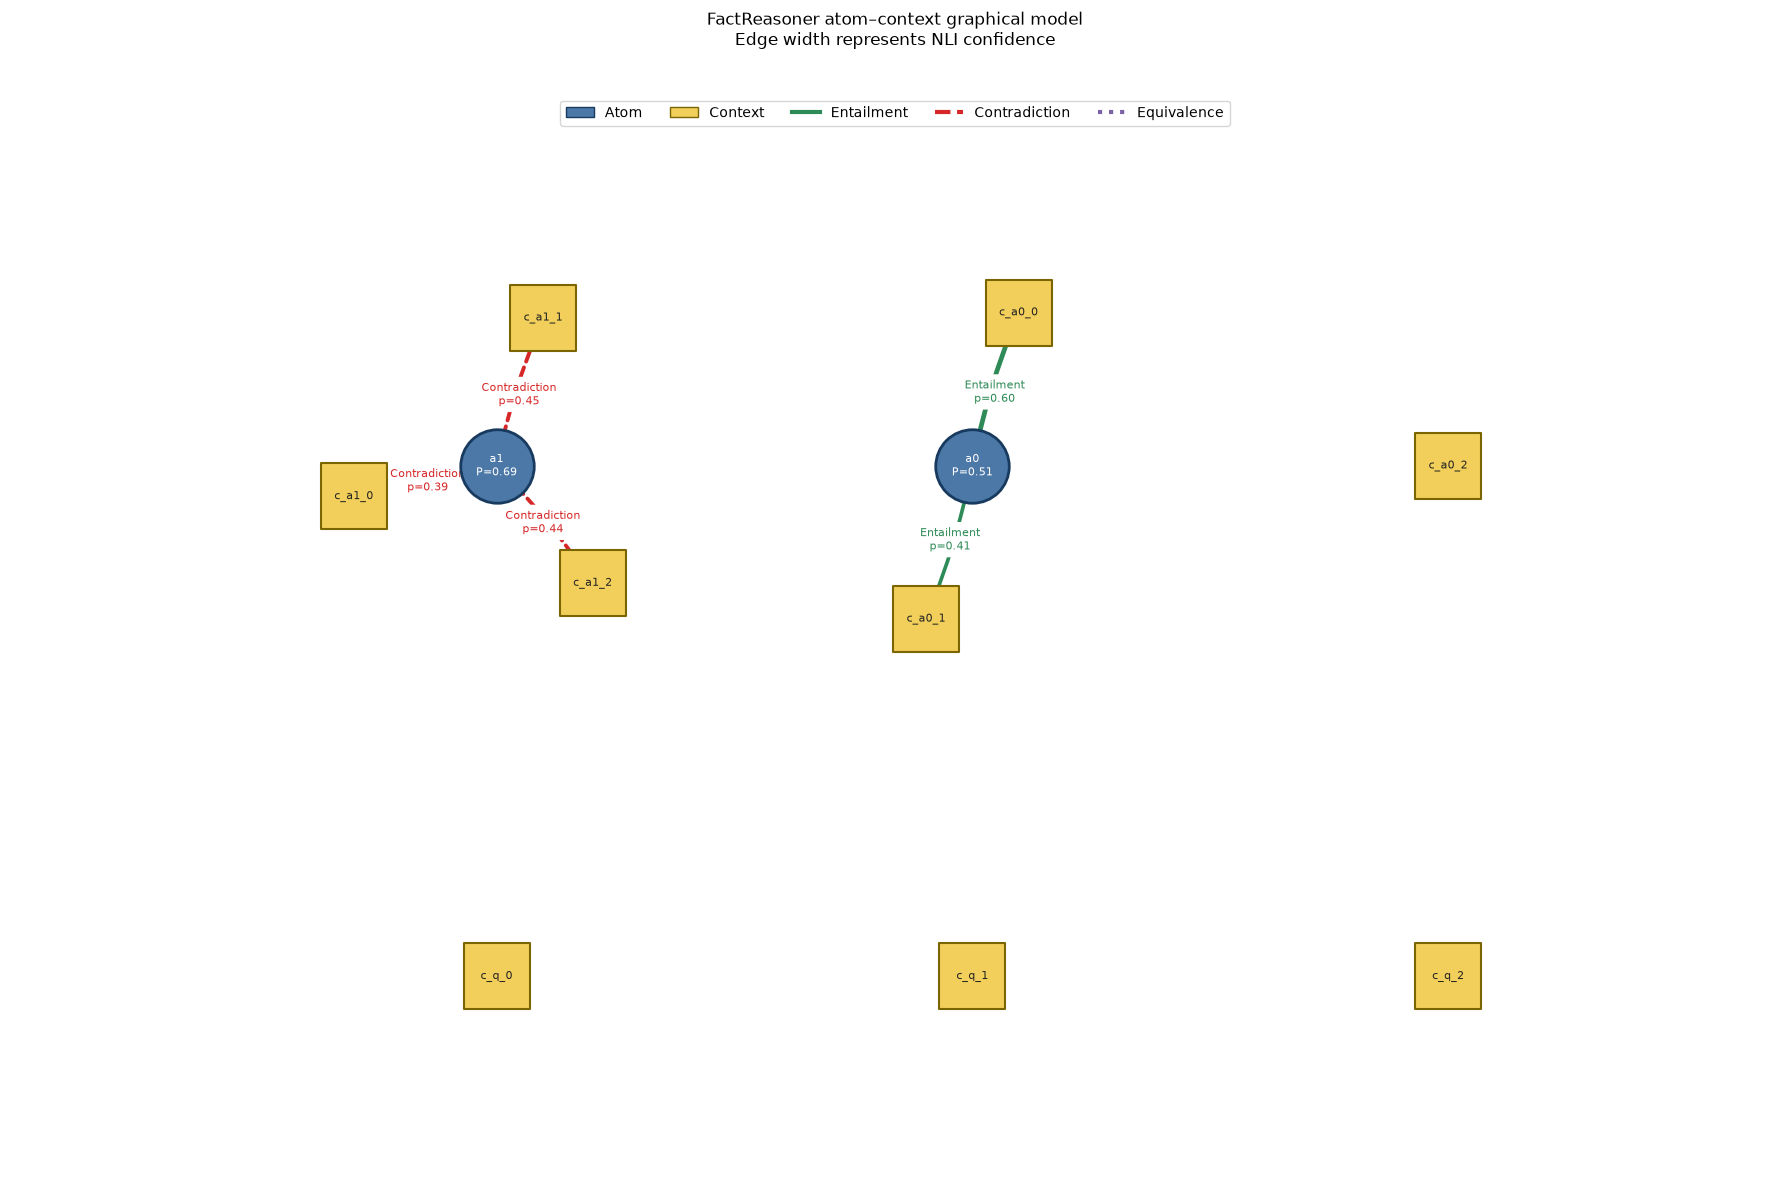

In [37]:
import textwrap

import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


RELATION_STYLES = {
    "entailment": {
        "color": "#2E8B57",
        "style": "solid",
        "label": "Entailment",
    },
    "contradiction": {
        "color": "#D62728",
        "style": "dashed",
        "label": "Contradiction",
    },
    "equivalence": {
        "color": "#7B61A8",
        "style": "dotted",
        "label": "Equivalence",
    },
}


def _relation_name(value):
    """Normalize strings and enum-like relation values."""
    return str(value).lower().split(".")[-1]


def _column_positions(node_ids, x):
    """Place nodes at evenly spaced positions in one column."""
    node_ids = list(node_ids)

    if len(node_ids) == 1:
        return {node_ids[0]: (x, 0.5)}

    return {
        node_id: (x, 1.0 - index / (len(node_ids) - 1))
        for index, node_id in enumerate(node_ids)
    }


def _wrap(text, width=27, max_lines=3):
    """Produce a short, wrapped node label."""
    lines = textwrap.wrap(" ".join((text or "").split()), width=width)
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] += "…"
    return "\n".join(lines)


def plot_factreasoner_graph(pipeline, results, figsize=(15, 9)):
    """Plot atoms, contexts, NLI relations, and atom posteriors."""

    if pipeline.fact_graph is None:
        raise RuntimeError(
            "The graph has not been built. Run assess_response(...) first."
        )

    fact_graph = pipeline.fact_graph

    atom_ids = sorted(
        node_id
        for node_id, node in fact_graph.nodes.items()
        if node.type == "atom"
    )
    context_ids = sorted(
        node_id
        for node_id, node in fact_graph.nodes.items()
        if node.type == "context"
    )

    # Extract P(atom=True) from the FactReasoner results.
    posterior = {}
    for item in results.get("factuality_score_per_atom", []):
        atom_id, payload = next(iter(item.items()))
        posterior[atom_id] = float(payload["score"])

    graph = nx.DiGraph()

    for node_id in atom_ids:
        graph.add_node(node_id, kind="atom")

    for node_id in context_ids:
        graph.add_node(node_id, kind="context")

    for edge in fact_graph.edges:
        graph.add_edge(
            edge.source,
            edge.target,
            relation=_relation_name(edge.type),
            confidence=float(edge.probability),
        )

    # Contexts on the left; atoms on the right.
    positions = separated_graph_layout(graph)
    fig, ax = plt.subplots(figsize=(18, 12))

    # Context nodes
    nx.draw_networkx_nodes(
        graph,
        positions,
        nodelist=context_ids,
        node_color="#F2CF5B",
        node_shape="s",
        node_size=2200,
        edgecolors="#7A6500",
        linewidths=1.5,
        ax=ax,
    )

    # Atom nodes
    nx.draw_networkx_nodes(
        graph,
        positions,
        nodelist=atom_ids,
        node_color="#4C78A8",
        node_shape="o",
        node_size=2800,
        edgecolors="#173A5E",
        linewidths=2.0,
        ax=ax,
    )

    context_labels = {
        context_id: context_id
        for context_id in context_ids
    }
    
    atom_labels = {
        atom_id: (
            f"{atom_id}\n"
            f"P={posterior.get(atom_id, float('nan')):.2f}"
        )
        for atom_id in atom_ids
    }

    nx.draw_networkx_labels(
        graph,
        positions,
        labels=context_labels,
        font_size=8,
        font_color="#222222",
        ax=ax,
    )

    nx.draw_networkx_labels(
        graph,
        positions,
        labels=atom_labels,
        font_size=8,
        font_color="white",
        ax=ax,
    )

    # Draw each relation type separately.
    for relation, appearance in RELATION_STYLES.items():
        relation_edges = [
            (source, target)
            for source, target, data in graph.edges(data=True)
            if data["relation"] == relation
        ]

        if not relation_edges:
            continue

        widths = [
            1.0 + 4.0 * graph.edges[edge]["confidence"]
            for edge in relation_edges
        ]

        nx.draw_networkx_edges(
            graph,
            positions,
            edgelist=relation_edges,
            edge_color=appearance["color"],
            style=appearance["style"],
            width=widths,
            arrows=True,
            arrowstyle="-|>",
            arrowsize=18,
            connectionstyle="arc3,rad=0.05",
            ax=ax,
        )

        edge_labels = {
            edge: (
                f"{appearance['label']}\n"
                f"p={graph.edges[edge]['confidence']:.2f}"
            )
            for edge in relation_edges
        }

        nx.draw_networkx_edge_labels(
            graph,
            positions,
            edge_labels=edge_labels,
            font_color=appearance["color"],
            font_size=8,
            rotate=False,
            label_pos=0.52,
            ax=ax,
        )

    legend = [
        Patch(
            facecolor="#4C78A8",
            edgecolor="#173A5E",
            label="Atom",
        ),
        Patch(
            facecolor="#F2CF5B",
            edgecolor="#7A6500",
            label="Context",
        ),
        Line2D(
            [0], [0],
            color="#2E8B57",
            linewidth=3,
            label="Entailment",
        ),
        Line2D(
            [0], [0],
            color="#D62728",
            linewidth=3,
            linestyle="--",
            label="Contradiction",
        ),
        Line2D(
            [0], [0],
            color="#7B61A8",
            linewidth=3,
            linestyle=":",
            label="Equivalence",
        ),
    ]

    ax.legend(handles=legend, loc="upper center", ncol=5)
    ax.set_title(
        "FactReasoner atom–context graphical model\n"
        "Edge width represents NLI confidence",
        pad=35,
    )

    ax.margins(0.30)
    ax.axis("off")
    plt.tight_layout()

    return fig, ax


plot_factreasoner_graph(pipeline, results)

### Discuss the result

Use these questions in pairs for five minutes:

1. Did the atomizer preserve the crucial words `before the feather` and `because it had greater mass`?
2. Does the displayed context actually support the NLI label?
3. Why is a contradicted claim represented by a probability rather than only `False`?
4. If the model gives an unexpected relation, is the problem retrieval, prompting, model capacity, or inference?
5. Would a second evidence source make you more confident, or could it introduce a conflict?

**Expected direction, not a guaranteed exact output:** the first claim should be supported: David Scott dropped the hammer and feather together during Apollo 15. The second should be contradicted: with negligible lunar air resistance, the hammer and feather struck the surface at the same time rather than the heavier object arriving first. Local generation is stochastic; a surprising result is useful evidence to inspect, not something to hide.

## 8. Why a run can look stuck

Let `A` be the number of atoms and `k` the contexts retrieved per atom, with approximately `C=A×k` contexts. Ignoring query-level contexts and deduplication:

- FR1 atom–context pairs: approximately `A×k`
- FR2 atom–context pairs: approximately `A×C`
- FR3 adds directed context–context pairs: approximately `C×(C−1)`

With FactReasoner's default SIMBA-UQ schedule, **each NLI pair requests twenty generations**: four temperatures (`[0.3, 0.5, 0.7, 1.0]`) times five samples per temperature. That multiplier is why a modest-looking batch can take a long time.

Yes, the sample count is configurable when constructing `NLIExtractor` directly:

- `simbauq_temperatures` controls the temperature schedule.
- `simbauq_n_per_temp` controls samples generated at each temperature.
- Total model generations per NLI pair are `len(temperatures) × n_per_temp`.

| Setting | Temperatures | Samples per temperature | Total per NLI pair |
|---|---|---:|---:|
| Minimal smoke test | `[0.3, 0.7]` | 1 | 2 |
| This tutorial | `[0.3, 0.7]` | 2 | 4 |
| FactReasoner default | `[0.3, 0.5, 0.7, 1.0]` | 5 | 20 |

Both values are public constructor parameters in FactReasoner 0.8.0. The temperature list must be non-empty and `n_per_temp` must be positive. Although aggregation mode technically permits one total sample, the implementation marks that confidence estimate as degraded; do not use one sample for a meaningful uncertainty estimate. Fewer samples run faster but make the consensus-derived confidence less stable. Four total samples are a pragmatic teaching setting, not a validated research default.

In [72]:
def approximate_cost(atoms, top_k, version):
    contexts = atoms * top_k
    if version == "v1":
        pairs = atoms * top_k
    elif version == "v2":
        pairs = atoms * contexts
    elif version == "v3":
        pairs = atoms * contexts + contexts * (contexts - 1)
    else:
        raise ValueError("version must be v1, v2, or v3")
    return {
        "atoms": atoms,
        "top_k": top_k,
        "version": version,
        "approx_NLI_pairs": pairs,
        "generations_tutorial_4_samples": pairs * SIMBA_SAMPLES_PER_PAIR,
        "generations_default_20_samples": pairs * 20,
    }

scenarios = [
    approximate_cost(2, 1, "v1"),
    approximate_cost(6, 3, "v2"),
    approximate_cost(6, 3, "v3"),
]
display(pd.DataFrame(scenarios))

,atoms,top_k,version,approx_NLI_pairs,generations_classroom_4_samples,generations_default_20_samples
0,2,1,v1,2,8,40
1,6,3,v2,108,432,2160
2,6,3,v3,414,1656,8280


## 9. Exercise: manually add evidence contexts

Add one or more passages to `STUDENT_CONTEXTS`. Every passage must include a title, text, short snippet, and traceable link. If you intentionally add a false or adversarial passage, label it prominently and use a `local://` link so it cannot be mistaken for a genuine source.

Before running:

1. Predict the NLI relation between each new passage and each atom.
2. Predict whether the new passage will raise or lower each atom's posterior.
3. Decide whether the passage is independent evidence or merely repeats an existing source.

Set `RUN_MANUAL_CONTEXT_EXERCISE = True`, run the cell, and compare the evidence, relations, and posteriors with the baseline run.

In [1]:
STUDENT_CONTEXTS = [
    {
        "title": "Replace with a descriptive title",
        "text": "",  # Paste or write the additional evidence here.
        "snippet": "",
        "link": "local://student-context-1",
    },
    # Copy the dictionary above to add more contexts.
]

RUN_MANUAL_CONTEXT_EXERCISE = False

student_contexts = [
    item for item in STUDENT_CONTEXTS
    if item.get("text", "").strip()
]

if RUN_MANUAL_CONTEXT_EXERCISE:
    if not student_contexts:
        raise ValueError(
            "Add at least one non-empty context to STUDENT_CONTEXTS."
        )

    manual_source = StaticEvidenceRetriever(
        [*OFFLINE_APOLLO_EVIDENCE, *student_contexts]
    )
    manual_pipeline, manual_results = await assess_response(
        RESPONSE,
        QUERY,
        TOPIC,
        source_retriever=manual_source,
    )
    show_result_tables(manual_pipeline, manual_results)
else:
    print(
        "Add evidence, write down your prediction, then set "
        "RUN_MANUAL_CONTEXT_EXERCISE=True."
    )


Add evidence, write down your prediction, then set RUN_MANUAL_CONTEXT_EXERCISE=True.


## 10. Exercise: retrieve live Wikipedia contexts

Leonardo compute nodes cannot reach Wikipedia. Run this exercise either:

- on a **personal laptop** with internet access, where the full live assessment may be run; or
- on a **Leonardo login node** as a short retrieval-only test.

CINECA permits only development, basic debugging, and very short tests on login nodes (normally under 10 minutes of CPU time). Do not run Ollama inference or the full FactReasoner assessment there.

Tasks:

1. Set `RUN_LIVE_RETRIEVAL_TEST = True`.
2. Compare the returned Wikipedia titles and passages with the fixed offline evidence.
3. On a personal laptop only, optionally set `RUN_FULL_LIVE_ASSESSMENT = True`.
4. Explain whether changes in the final score originate in retrieval, NLI confidence, or inference.


In [4]:
RUN_LIVE_RETRIEVAL_TEST = False
RUN_FULL_LIVE_ASSESSMENT = False  # Personal laptop only.

if RUN_LIVE_RETRIEVAL_TEST:
    live_source = make_source_retriever("wikipedia", top_k=3)
    live_hits = live_source.query(TOPIC)

    if not live_hits:
        raise RuntimeError(
            "Wikipedia returned no contexts. Check that this machine has "
            "outbound internet access."
        )

    display(pd.DataFrame([
        {
            "title": hit["title"],
            "preview": shorten(hit["text"]),
            "link": hit["link"],
        }
        for hit in live_hits
    ]))

    if RUN_FULL_LIVE_ASSESSMENT:
        live_pipeline, live_results = await assess_response(
            RESPONSE,
            QUERY,
            TOPIC,
            source_retriever=live_source,
        )
        show_result_tables(live_pipeline, live_results)
else:
    print(
        "Run on a personal laptop or as a short login-node retrieval test. "
        "Then set RUN_LIVE_RETRIEVAL_TEST=True."
    )


Run on a personal laptop or as a short login-node retrieval test. Then set RUN_LIVE_RETRIEVAL_TEST=True.


## 11. Challenge

Choose one change, predict the result, then set `RUN_CHALLENGE=True`.

- **Correction:** replace `before the feather` with `at the same time as the feather`.
- **Environment change:** move the experiment to ordinary air on Earth and discuss why drag changes the observation.
- **Physics extension:** claim that equal acceleration means the Moon has no gravity, then distinguish gravity from air resistance.
- **Uncertainty test:** claim an exact 1.400 s fall time even though release simultaneity, height, and video timing have finite precision.

Keep the response to two short claims so the classroom oracle and local model remain fast.

In [2]:
CHALLENGE_RESPONSE = (
    "The Apollo 15 hammer and feather struck the lunar surface at the same time. "
    "They fell together because the Moon has no gravity."
)
RUN_CHALLENGE = False  # change to True after writing down your prediction

if RUN_CHALLENGE:
    challenge_pipeline, challenge_results = await assess_response(
        CHALLENGE_RESPONSE, QUERY, TOPIC
    )
    show_result_tables(challenge_pipeline, challenge_results)
else:
    print("Prediction first. Then set RUN_CHALLENGE=True and rerun this cell.")

Prediction first. Then set RUN_CHALLENGE=True and rerun this cell.


## 12. Move from tutorial mode to a real experiment

| Setting | Production/research direction |
|---|---|
| Exact brute-force fallback allowed | Compile and use the real Merlin executable |
| Two short claims | Representative evaluation dataset |
| Wikipedia, `top_k=1` | Audited source collection; increase `top_k` carefully |
| FR1 | Start with FR2; use FR3 only when context–context reasoning is needed |
| Four SIMBA samples per pair | Default twenty samples, or another task-validated sampling configuration |
| One exploratory run | Repeat runs, log configuration, and retain evidence |
| `all_pairs` on a tiny graph | Iterate with `fast`; confirm final results with `all_pairs` |

The high-level API for a real Ollama run is:

```python
from fact_reasoner import FactualityRunner, build_backend
from mellea.backends import ModelOption

runner = FactualityRunner(
    build_backend(
        "ollama",
        model_id="qwen2.5:1.5b",
        model_options={ModelOption.MAX_NEW_TOKENS: 512},
    ),
    pipeline="factreasoner",
    pipeline_version="v2",
    service_type="wikipedia",
    top_k=2,
    use_summarizer=False,
    merlin_path="/absolute/path/to/merlin",
    nli_method="simbauq",  # required for meaningful Ollama NLI probabilities
    nli_mode="fast",
    nli_cache_dir=".cache/factreasoner-nli",
)

results = runner.assess(query=QUERY, response=RESPONSE, topic=TOPIC)
```

In FactReasoner 0.8.0, `FactualityRunner` exposes the SIMBA-UQ method and similarity metric but not the temperature schedule or per-temperature sample count. Therefore this high-level example uses the default twenty-sample budget. Use the explicit `NLIExtractor` component construction shown earlier when you need to change the number of SIMBA-UQ samples.

## Appendix A. Troubleshooting

| Symptom | Meaning | Action |
|---|---|---|
| `bash: ollama: command not found` | User-space Ollama is not on the shell `PATH` | Use `$HOME/.local/ollama/bin/ollama`, or export the paths shown in the install section |
| `could not connect to ollama server` | Ollama is installed but no server is running on this compute node | Rerun the runtime-bootstrap cell; verify `curl http://127.0.0.1:11434/api/tags` |
| Model absent in preflight | Server is running but shared scratch does not contain the tag | Pull `qwen2.5:1.5b` from the login node into `$SCRATCH/ollama-models`, not from the compute node |
| `Network is unreachable` from `pip`, `uv`, or `ollama pull` | The compute node has no outbound route to PyPI or the Ollama registry | Perform package and model downloads from the login node, then use the shared environment/model paths |
| `Running throttled batch ...` for a long time | Many NLI requests are queued | Wait and watch CPU/GPU use; reduce atoms or `top_k`; use FR1/`fast`; keep the NLI cache |
| All relations appear neutral | Ollama was used with `nli_method="logprobs"` | Recreate the pipeline with `nli_method="simbauq"` |
| `ModuleNotFoundError: fact_reasoner` or Python 3.10 | Jupyter is using the old `RLenv` kernel | Select **Python 3.11 (FactReasoner)**; `sys.executable` must point to `$HOME/.venvs/fact-reasoner/bin/python` |
| `bash: cmake: command not found` | CMake is missing | Install with Homebrew, system packages, or Conda/Micromamba |
| Merlin exits non-zero | Bad executable path or incompatible build | Run the executable's `--help`; use an absolute `MERLIN_PATH`; rebuild in Release mode |
| Wikipedia returns no contexts | Compute-node network, disambiguation, or query problem | Verify that the compute node can reach Wikipedia; make claims more self-contained; try a better-known entity |
| Results change between runs | Local generation and reduced SIMBA sampling are stochastic | Use the cache, restore the default sampling budget, and repeat experiments |

If you interrupt an NLI cell, create a **fresh pipeline** before retrying. The helper in this notebook already does that.

## Recap

In one sentence each, answer:

1. Why is an atom's posterior not the same as objective truth?
2. How do token log-probabilities and SIMBA-UQ aggregation estimate NLI confidence differently, and why does Ollama require the latter here?
3. When would a trained SIMBA-UQ classifier be preferable to similarity aggregation?
4. How is relation confidence different from the posterior probability and entropy of an atom?
5. Which knobs control graph shape, NLI pair count, and samples per NLI pair—and what would you log for reproducibility?

### Primary sources

- [IBM FactReasoner repository](https://github.com/IBM/FactReasoner)
- [FactReasoner 0.8.0 on PyPI](https://pypi.org/project/fact_reasoner/0.8.0/)
- [Merlin probabilistic inference engine](https://github.com/radum2275/merlin)
- [Ollama quickstart](https://docs.ollama.com/quickstart)
- [Ollama `qwen2.5:1.5b` model](https://ollama.com/library/qwen2.5:1.5b)
- [Qwen2.5 1.5B Instruct model card](https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct)
- [NASA Apollo 15 hammer-and-feather experiment record and video](https://science.nasa.gov/resource/the-apollo-15-hammer-feather-drop/)
- [NASA Apollo 15 history and experiment still](https://www.nasa.gov/history/50-years-ago-apollo-15-on-the-moon-at-hadley-apennine/)
- [NASA image and media usage guidelines](https://www.nasa.gov/nasa-brand-center/images-and-media/)

**Takeaway:** FactReasoner is most useful when the score is treated as the end of a traceable evidence-and-reasoning process, not as an unexplained grade.